# BP plc: Commodity Risk Modelling and Equity Valuation

## Analysis objective

This notebook investigates how BP's equity returns respond to changes in Brent crude oil prices and whether that relationship changes through time or across different market environments.

The analysis aims to:

1. Estimate BP's weekly Brent sensitivity while controlling for FTSE 100 and GBP/USD movements.

2. Test whether BP's Brent exposure is stable through time using rolling regressions.

3. Test whether Brent sensitivity changes across oil-price regimes and other market conditions.

4. Compare competing specifications using expanding-window walk-forward validation and a reserved 2024–2026 holdout period.

5. Use the resulting evidence to inform commodity-price scenario design in the subsequent BP DCF valuation.

## 1. Data collection

Daily adjusted prices for BP's London-listed shares, the FTSE 100 and GBP/USD are collected from Yahoo Finance, while Brent crude-oil spot prices are obtained from FRED.

Brent is included as the primary commodity factor because oil prices are a key driver of BP's economic environment. The FTSE 100 controls for broad UK equity-market movements that may affect BP independently of oil.

GBP/USD is included because BP's London-listed shares are priced in sterling, while the group identifies the US dollar as the main underlying economic currency of its cash flows, reflecting the international pricing of oil in US dollars. The exchange-rate series therefore controls for potential currency effects between BP's underlying dollar-linked economics and its sterling-denominated equity return.

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import yfinance as yf

from pandas_datareader import data as pdr
from pathlib import Path
from statsmodels.regression.rolling import RollingOLS
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [88]:
START_DATE = "2014-01-01"
END_DATE = "2026-08-20"

In [89]:
PROCESSED_DATA_DIR = Path("data") / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [90]:
market_data = yf.download(
    ["BP.L", "^FTSE", "GBPUSD=X"],
    start=START_DATE,
    end=END_DATE,
    progress = False,
    auto_adjust=True  # Adjusted equity prices for corporate actions
)

market_prices = market_data["Close"].copy()

market_prices = market_prices.rename(columns={
    "BP.L": "BP_GBP", 
    "^FTSE": "FTSE100",
    "GBPUSD=X": "GBPUSD"
})

market_prices.head()

Ticker,BP_GBP,GBPUSD,FTSE100
Date,,,
2014-01-01,NaN,1.656397,NaN
2014-01-02,485.221313,1.658072,6717.899902
2014-01-03,484.278473,1.644791,6730.700195
2014-01-06,485.320740,1.641309,6730.700195
2014-01-07,490.333160,1.641794,6755.500000


In [91]:
brent_data = pdr.DataReader(
    "DCOILBRENTEU",
    "fred",
    start=START_DATE,       
    end=END_DATE
)

brent_data = brent_data.rename(columns={
    "DCOILBRENTEU": "Brent_USD"
})

brent_data.head()

,Brent_USD
DATE,
2014-01-01,NaN
2014-01-02,107.94
2014-01-03,106.57
2014-01-06,106.71
2014-01-07,107.01


## 2. Data preparation

The daily series come from different markets and data sources, so their trading calendars do not align perfectly. An outer join is used to preserve all available dates before the data are resampled to Friday-ending weeks. This avoids unnecessarily discarding valid observations simply because BP, FX and Brent do not always share the same trading days.

Weekly frequency is used to reduce short-term daily noise while retaining enough observations to analyse changes in BP's commodity exposure through time. End-of-week prices are used to calculate weekly log returns:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns provide a consistent measure of proportional price changes across BP, Brent, the FTSE 100 and GBP/USD, and are approximately equal to percentage returns for small weekly movements.

A separate weekly average Brent price is retained for the later price-regime analysis. Returns measure how much Brent changes from one week to the next, while the weekly average price represents the prevailing oil-price environment used to classify observations into low-, medium- and high-price regimes.

In [92]:
# Outer join preserves all dates across daily series, exposing non-overlapping observations
daily_data = market_prices.join(brent_data, how="outer")

# Missing-value counts reveal calendar and data-source mismatches before resampling
daily_data.isna().sum()

BP_GBP       106
GBPUSD         9
FTSE100      106
Brent_USD     89
dtype: int64

In [93]:
# Last available weekly observation provides the end-of-period price for return calculation
weekly_data = daily_data.resample("W-FRI").last()

# Weekly mean represents the prevailing Brent price level for regime classification
weekly_data["Brent_USD_Avg"] = daily_data["Brent_USD"].resample("W-FRI").mean()

weekly_data.isna().sum()

BP_GBP           0
GBPUSD           0
FTSE100          0
Brent_USD        0
Brent_USD_Avg    0
dtype: int64

In [94]:
# Weekly log returns are used for time-additive and scale-comparable price changes
weekly_data["Brent_Return"] = np.log(weekly_data["Brent_USD"] / weekly_data["Brent_USD"].shift(1))
weekly_data["BP_Return"] = np.log(weekly_data["BP_GBP"] / weekly_data["BP_GBP"].shift(1))
weekly_data["FTSE_Return"] = np.log(weekly_data["FTSE100"] / weekly_data["FTSE100"].shift(1))
weekly_data["FX_Return"] = np.log(weekly_data["GBPUSD"] / weekly_data["GBPUSD"].shift(1))

# Complete return observations are retained for subsequent modelling
weekly_data = weekly_data.dropna(subset=["Brent_Return", "BP_Return", "FTSE_Return", "FX_Return"])

OUTPUT_FILE = PROCESSED_DATA_DIR / "bp_brent_weekly.csv"
weekly_data.to_csv(OUTPUT_FILE, index=True)

weekly_data.head()

,BP_GBP,GBPUSD,FTSE100,Brent_USD,Brent_USD_Avg,Brent_Return,BP_Return,FTSE_Return,FX_Return
Date,,,,,,,,,
2014-01-10,493.310913,1.647908,6739.899902,106.44,107.014,-0.001221,0.018480,0.001366,0.001893
2014-01-17,487.405029,1.635296,6829.299805,108.45,107.828,0.018708,-0.012044,0.013177,-0.007683
2014-01-24,483.037750,1.663478,6663.700195,109.14,109.140,0.006342,-0.009001,-0.024547,0.017087
2014-01-31,474.451965,1.649838,6510.399902,108.16,108.834,-0.009020,-0.017934,-0.023274,-0.008234
2014-02-07,478.124298,1.632200,6571.700195,110.12,107.734,0.017959,0.007710,0.009372,-0.010749


## 3. Exploratory analysis

Before estimating BP's controlled commodity exposure, the return series are examined to understand their volatility, distribution and basic co-movement.

Summary statistics are used to compare the scale and dispersion of weekly returns, while the correlation matrix provides an initial view of BP's pairwise relationship with Brent, the FTSE 100 and GBP/USD. These correlations are descriptive only: they do not isolate Brent exposure from broader market movements, which is why the multivariate regression is required later.

A BP-Brent scatter plot is used to inspect the shape and dispersion of their contemporaneous relationship, while a 52-week rolling correlation is used to assess whether their co-movement appears stable through time.

In [95]:
return_columns = [
    "Brent_Return",
    "BP_Return",
    "FTSE_Return",     
    "FX_Return"
]

summary_stats = weekly_data[return_columns].describe().T
correlation_matrix = weekly_data[return_columns].corr()

display(summary_stats)
display(correlation_matrix)

,count,mean,std,min,25%,50%,75%,max
Brent_Return,659.0,-0.000190,0.057383,-0.346390,-0.027317,0.002464,0.030124,0.294459
BP_Return,659.0,0.000163,0.041799,-0.357905,-0.020806,0.001383,0.021861,0.193712
FTSE_Return,659.0,0.000710,0.020567,-0.185930,-0.008726,0.002441,0.011938,0.075928
FX_Return,659.0,-0.000296,0.012573,-0.089473,-0.007313,-0.000595,0.007405,0.059629


,Brent_Return,BP_Return,FTSE_Return,FX_Return
Brent_Return,1.000000,0.503677,0.258598,0.102857
BP_Return,0.503677,1.000000,0.650380,-0.026823
FTSE_Return,0.258598,0.650380,1.000000,-0.007875
FX_Return,0.102857,-0.026823,-0.007875,1.000000


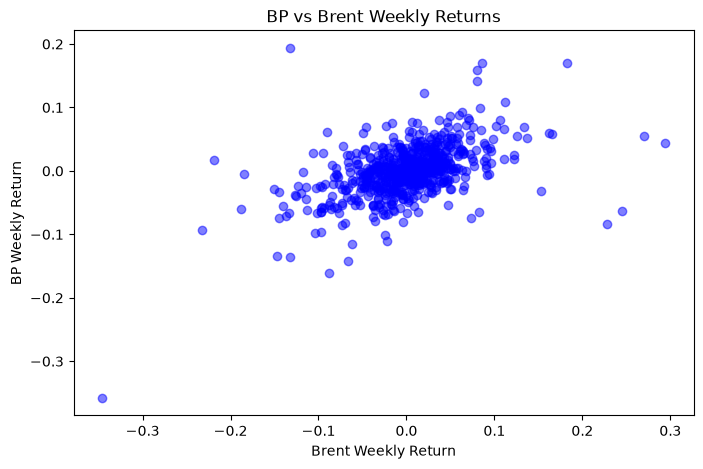

In [96]:
plt.figure(figsize=(8, 5))

plt.scatter(weekly_data["Brent_Return"], weekly_data["BP_Return"], alpha=0.5, color="blue")

plt.title("BP vs Brent Weekly Returns")
plt.xlabel("Brent Weekly Return")   
plt.ylabel("BP Weekly Return")

plt.show()

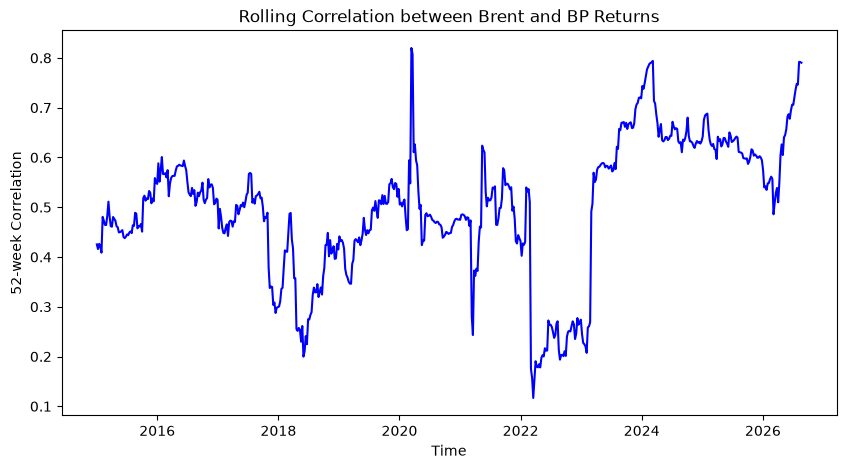

In [97]:
rolling_correlation = weekly_data["Brent_Return"].rolling(window=52).corr(weekly_data["BP_Return"])

plt.figure(figsize=(10, 5))
plt.plot(rolling_correlation.index, rolling_correlation, color="blue", label="Rolling Correlation (52 weeks)")
plt.title("Rolling Correlation between Brent and BP Returns")
plt.xlabel("Time")
plt.ylabel("52-week Correlation")
plt.show()

BP is positively correlated with both Brent and the FTSE 100, with the stronger relationship observed against the broader equity market. The BP-Brent scatter also shows a positive but dispersed relationship, while the rolling correlation varies materially through time.

These results suggest that Brent is relevant to BP's equity returns, but simple correlation cannot distinguish oil-price exposure from movements shared with the wider market. A multivariate model is therefore used to estimate BP's Brent sensitivity while controlling for the FTSE 100 and GBP/USD.

## 4. Baseline commodity-exposure model

A multivariate OLS model is used to estimate BP's contemporaneous weekly Brent exposure while holding broad UK equity-market and exchange-rate movements constant:

$$
r^{BP}_t
=
\alpha
+
\beta_B r^{Brent}_t
+
\beta_M r^{FTSE}_t
+
\beta_X r^{FX}_t
+
\varepsilon_t
$$

The coefficient $\beta_B$ therefore measures the estimated change in BP's weekly return associated with a 1% change in Brent, after accounting for simultaneous FTSE 100 and GBP/USD movements.

In [98]:
X = weekly_data[["Brent_Return", "FTSE_Return", "FX_Return"]]
X = sm.add_constant(X)  # Constant column allows estimation of the regression intercept
y = weekly_data["BP_Return"]

baseline_model = sm.OLS(y, X).fit()

baseline_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              BP_Return   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     263.8
Date:                Tue, 01 Sep 2026   Prob (F-statistic):          3.12e-112
Time:                        15:58:06   Log-Likelihood:                 1418.7
No. Observations:                 659   AIC:                            -2829.
Df Residuals:                     655   BIC:                            -2811.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0006      0.001     -0.587      0.557      -0.003       0.002
Brent_Return     0.2668      0.020     13.378      0.000       0.228       0.306
FTSE_Return      1.1283      0.055     20.384      0.000       1.020       1.237
FX_Return       -0.1999      0.088     -2.273      0.023      -0.373      -0.027
==============================================================================
Omnibus:                       74.834   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              359.665
Skew:                           0.373   Prob(JB):                     7.94e-79
Kurtosis:                       6.541   Cond. No.                         80.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The baseline model explains approximately 55% of the variation in weekly BP returns. The Brent coefficient is 0.267, while the FTSE 100 coefficient is 1.128, showing that both commodity and broader market movements are economically important.

GBP/USD appears significant under conventional OLS standard errors, but the robustness of that result is tested later using HAC inference.

## 5. Time-varying commodity exposure

Since the baseline OLS model estimates a single average Brent sensitivity across the full sample, the same regression is re-estimated over rolling 52-week windows to examine whether this exposure changes through time

This produces a time-varying Brent beta, rather than the raw BP-Brent co-movement measured by the earlier rolling correlation.

In [99]:
rolling_X = weekly_data[["Brent_Return", "FTSE_Return", "FX_Return"]]
rolling_X = sm.add_constant(rolling_X)  

# Rolling regressions estimate time-varying factor sensitivities over trailing 52-week windows
rolling_model = RollingOLS(y, rolling_X, window=52).fit()

rolling_betas = rolling_model.params

rolling_betas.dropna().head()

,const,Brent_Return,FTSE_Return,FX_Return
Date,,,,
2015-01-02,0.000306,0.198158,1.145171,0.497921
2015-01-09,-0.000530,0.149487,1.155661,0.346618
2015-01-16,0.000804,0.168935,1.182453,0.326894
2015-01-23,0.000397,0.167414,1.201755,0.256507
2015-01-30,-0.000206,0.152757,1.234204,0.294259


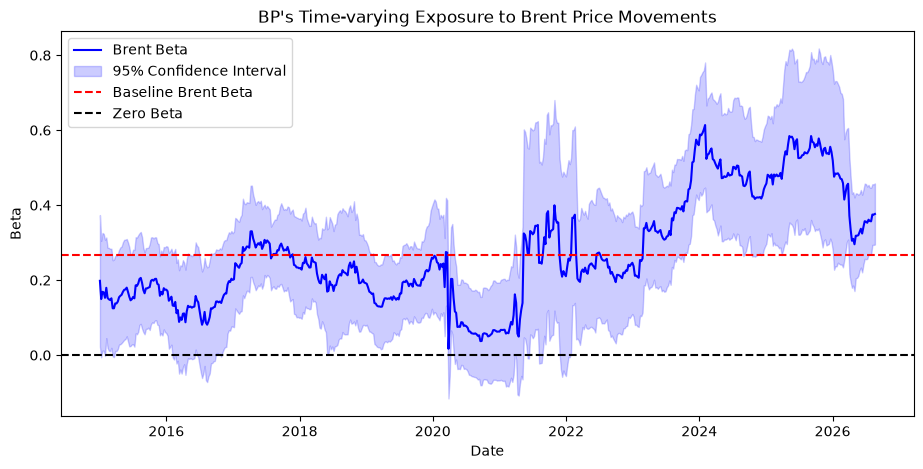

count    608.000000
mean       0.273326
std        0.143979
min        0.016852
25%        0.168661
50%        0.238504
75%        0.357601
max        0.613688
Name: Brent_Return, dtype: float64

In [100]:
rolling_brent_beta = rolling_betas["Brent_Return"]
rolling_brent_se = rolling_model.bse["Brent_Return"]

rolling_ci_lower = rolling_brent_beta - 1.96 * rolling_brent_se
rolling_ci_upper = rolling_brent_beta + 1.96 * rolling_brent_se

plt.figure(figsize=(11, 5))

plt.plot(rolling_betas.index, rolling_brent_beta, label="Brent Beta", color="blue")

# Confidence band shows estimation uncertainty around each rolling Brent beta
plt.fill_between(rolling_betas.index, rolling_ci_lower, rolling_ci_upper, 
                 color="blue", alpha=0.2, label="95% Confidence Interval")

# Full-sample Brent beta provides a benchmark for rolling exposure estimates
plt.axhline(y=baseline_model.params["Brent_Return"], color="red", 
            linestyle="--", label="Baseline Brent Beta")

plt.axhline(y=0, color="black", linestyle="--", label="Zero Beta")

plt.title("BP's Time-varying Exposure to Brent Price Movements")    
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.show()      

rolling_betas["Brent_Return"].describe()

The 52-week Brent beta averages 0.273, close to the full-sample estimate of 0.267, but the rolling estimates vary substantially through time, ranging from approximately 0.02 to 0.61.

The graph shows extended periods in which BP's estimated Brent sensitivity lies below the full-sample coefficient, particularly around 2015–2016 and 2018–2021, followed by a marked increase from 2023 and substantially higher exposure through much of 2024–2025.

The 95% confidence band also changes considerably through time. Around 2020–2021 it widens and briefly includes zero, indicating greater uncertainty around the local Brent exposure during that period. In later high-beta periods, the estimates are more clearly positive.

The full-sample coefficient therefore provides a useful average exposure measure, but masks economically meaningful variation in the strength and precision of BP's Brent sensitivity over time.

### 5.1 Rolling-window sensitivity

The rolling analysis is repeated using shorter and longer windows to test whether this pattern is driven by the 52-week choice. Shorter windows should react more quickly but produce noisier estimates, while longer windows should be smoother.

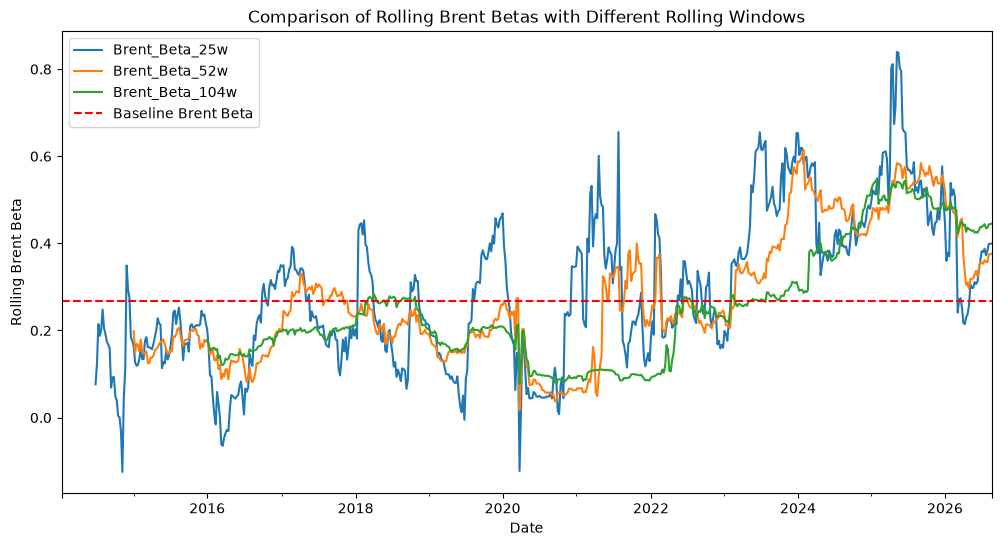

,mean,std,min,max
Brent_Beta_25w,0.289914,0.173646,-0.124738,0.839444
Brent_Beta_52w,0.273326,0.143979,0.016852,0.613688
Brent_Beta_104w,0.252504,0.131588,0.077439,0.549439


In [101]:
# Alternative windows test whether time-varying Brent exposure depends on the 52-week specification
rolling_windows = [25, 52, 104]  # 6 months, 1 year, 2 years

rolling_beta_comparison = pd.DataFrame(index=weekly_data.index)

for window in rolling_windows:
    rolling_model_window = RollingOLS(y, rolling_X, window=window).fit()
    rolling_beta_comparison[f"Brent_Beta_{window}w"] = rolling_model_window.params["Brent_Return"]

    rolling_beta_comparison[f"Brent_Beta_{window}w"] = (rolling_model_window.params["Brent_Return"])

rolling_beta_comparison.plot(figsize=(12, 6))

plt.axhline(y=baseline_model.params["Brent_Return"], color="red", linestyle="--", label="Baseline Brent Beta")

plt.title("Comparison of Rolling Brent Betas with Different Rolling Windows")
plt.xlabel("Date")
plt.ylabel("Rolling Brent Beta")
plt.legend()
plt.show()

rolling_beta_summary = (rolling_beta_comparison.describe().T[["mean", "std", "min", "max"]])

display(rolling_beta_summary)

The average Brent beta is relatively stable across the three specifications, ranging from 0.253 for the 104-week window to 0.290 for the 25-week window. In contrast, the dispersion falls as the window length increases: the standard deviation declines from 0.174 to 0.132, and the extreme 25-week estimates range from -0.125 to 0.839.

The sharp movements in the 25-week beta around 2020–2021 are therefore much less persistent in the longer-window estimates, suggesting that some short-run changes reflect temporary market conditions rather than lasting shifts in BP's exposure.

More importantly, all three specifications rise above the full-sample Brent beta from around 2023 and remain elevated through much of 2024–2025. The fact that this increase is visible even in the slower-moving 104-week estimate provides stronger evidence of a sustained increase in BP's Brent sensitivity rather than a result driven only by the choice of rolling window.


## 6. Asymmetric commodity exposure

The baseline model treats positive and negative Brent returns symmetrically. Separate upward and downward Brent components are introduced to test whether BP's sensitivity differs depending on the direction of the oil-price move.

In [102]:
 # Retain only positive Brent returns for regime classification
weekly_data["Brent_Up"] = weekly_data["Brent_Return"].clip(lower=0) 
# Retain only negative Brent returns for regime classification
weekly_data["Brent_Down"] = weekly_data["Brent_Return"].clip(upper=0)  

X_asym = weekly_data[["Brent_Up", "Brent_Down", "FTSE_Return", "FX_Return"]]
X_asym = sm.add_constant(X_asym)  # Constant column allows estimation of the regression intercept

asymmetric_model = sm.OLS(y, X_asym).fit()

# Coefficient estimates, standard errors, confidence intervals, and p-values for the asymmetric model
asymmetric_ci = asymmetric_model.conf_int()

asymmetric_results = pd.DataFrame({
    "Coefficient": asymmetric_model.params,
    "Std_Error": asymmetric_model.bse,
    "CI_Lower": asymmetric_ci[0],
    "CI_Upper": asymmetric_ci[1],
    "P_Value": asymmetric_model.pvalues
})

# Test whether BP's Brent sensitivity differs between upward and downward moves
asymmetry_test = asymmetric_model.t_test("Brent_Up = Brent_Down")
print(asymmetry_test)

# Compare model fit against the baseline specification
model_fit_comparison = pd.DataFrame({
    "Model": ["Baseline", "Asymmetric"],
    "R_Squared": [baseline_model.rsquared, asymmetric_model.rsquared],
    "Adj_R_Squared": [baseline_model.rsquared_adj, asymmetric_model.rsquared_adj]
})  
display(model_fit_comparison)

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0442      0.055      0.796      0.426      -0.065       0.153


,Model,R_Squared,Adj_R_Squared
0,Baseline,0.547186,0.545112
1,Asymmetric,0.547625,0.544858


The estimated difference between the upward and downward Brent coefficients is 0.044, but the equality test is not statistically significant ($p = 0.426$). The 95% confidence interval for the difference also includes zero, ranging from -0.065 to 0.153.

Model fit is essentially unchanged: $R^2$ rises only from 0.5472 in the baseline model to 0.5476 in the asymmetric specification, while adjusted $R^2$ actually falls slightly from 0.5451 to 0.5449.

The data therefore provide no meaningful evidence that BP responds differently to positive and negative Brent moves. Splitting Brent returns by direction adds complexity without improving explanatory power.

## 7. Brent price-regime analysis

Directional asymmetry asks whether rising and falling Brent prices have different effects. The regime analysis asks a different question: whether BP's Brent sensitivity depends on the prevailing level of oil prices.

Weekly average Brent prices are divided into low-, medium- and high-price regimes, and a pooled interaction model is then used to formally test whether the Brent slope changes across those environments.

In [103]:
# Brent price terciles define balanced low-, medium- and high-price environments
weekly_data["Brent_regime"] = pd.qcut(weekly_data["Brent_USD_Avg"], q=3, labels=["Low", "Medium", "High"])

regime_summary = weekly_data.groupby("Brent_regime")["Brent_USD_Avg"].agg(["min", "max", "mean", "count"])

display(regime_summary)

,min,max,mean,count
Brent_regime,,,,
Low,14.236,61.380,48.023055,220
Medium,61.412,76.596,69.186727,219
High,76.630,127.398,93.394439,220


In [104]:
# Estimate Brent sensitivity separately within each price regime
regime_results = []

for regime in ["Low", "Medium", "High"]:
    regime_data = weekly_data[weekly_data["Brent_regime"] == regime]
    
    X_regime = regime_data[["Brent_Return", "FTSE_Return", "FX_Return"]]
    X_regime = sm.add_constant(X_regime)
    y_regime = regime_data["BP_Return"]
    
    regime_model = sm.OLS(y_regime, X_regime).fit()

    regime_ci = regime_model.conf_int()
    regime_results.append({
        "Regime": regime,
        "Coefficient": regime_model.params["Brent_Return"],
        "Std_Error": regime_model.bse["Brent_Return"],
        "CI_Lower": regime_ci.loc["Brent_Return", 0],
        "CI_Upper": regime_ci.loc["Brent_Return", 1],
        "P_Value": regime_model.pvalues["Brent_Return"]
    })

regime_results = pd.DataFrame(regime_results)

display(regime_results)

,Regime,Coefficient,Std_Error,CI_Lower,CI_Upper,P_Value
0,Low,0.119791,0.032676,0.055386,0.184195,3.101179e-04
1,Medium,0.374488,0.043035,0.289663,0.459313,8.608226e-16
2,High,0.350301,0.030892,0.289414,0.411189,1.090106e-23


In [105]:
# Low-price regime is the reference category for the pooled interaction model
regime_dummies = pd.get_dummies(weekly_data["Brent_regime"], drop_first=True, dtype=float)

# Interaction terms test whether Brent sensitivity differs from the low-price regime
X_regime_test = pd.DataFrame({
    "Brent_Return": weekly_data["Brent_Return"],
    "FTSE_Return": weekly_data["FTSE_Return"],
    "FX_Return": weekly_data["FX_Return"],
    "Medium_Regime": regime_dummies["Medium"],
    "High_Regime": regime_dummies["High"],
    "Brent_x_Medium": weekly_data["Brent_Return"] * regime_dummies["Medium"],
    "Brent_x_High": weekly_data["Brent_Return"] * regime_dummies["High"]
})

X_regime_test = sm.add_constant(X_regime_test)

regime_interaction_model = sm.OLS(y, X_regime_test).fit()

regime_interaction_ci = regime_interaction_model.conf_int()

regime_interaction_results = pd.DataFrame({
    "Coefficient": regime_interaction_model.params,
    "Std_Error": regime_interaction_model.bse,
    "CI_Lower": regime_interaction_ci[0],
    "CI_Upper": regime_interaction_ci[1],
    "P_Value": regime_interaction_model.pvalues
})

display(regime_interaction_results)

regime_joint_test = regime_interaction_model.f_test("Brent_x_Medium = Brent_x_High = 0")
print(regime_joint_test)

,Coefficient,Std_Error,CI_Lower,CI_Upper,P_Value
const,-0.002006,0.001872,-0.005681,0.001669,2.842508e-01
Brent_Return,0.166871,0.028552,0.110807,0.222936,8.033694e-09
FTSE_Return,1.184357,0.056100,1.074199,1.294516,9.154695e-76
FX_Return,-0.155426,0.087110,-0.326477,0.015626,7.485114e-02
Medium_Regime,0.000890,0.002651,-0.004316,0.006096,7.371841e-01
High_Regime,0.003079,0.002647,-0.002119,0.008278,2.452009e-01
Brent_x_Medium,0.181955,0.052132,0.079588,0.284321,5.150845e-04
Brent_x_High,0.188645,0.044045,0.102157,0.275133,2.122135e-05


<F test: F=11.563433718794956, p=1.162008067140543e-05, df_denom=651, df_num=2>


The regime-specific regressions show a clear increase in BP's Brent sensitivity as the prevailing oil-price level moves out of the low regime. The estimated Brent beta is 0.120 in the low-price regime, compared with 0.374 in the medium-price regime and 0.350 in the high-price regime.

The pooled interaction model formally confirms this difference. With the low-price regime as the reference, the Brent interaction coefficients are 0.182 for the medium regime ($p < 0.001$) and 0.189 for the high regime ($p < 0.001$). This implies pooled Brent sensitivities of approximately 0.167 in the low regime, 0.349 in the medium regime and 0.356 in the high regime.

The two interaction terms are also jointly significant ($F = 11.56$, $p < 0.001$), providing strong evidence that BP's Brent sensitivity is not constant across oil-price regimes.

Medium- and high-price sensitivities are very similar, so the result is better interpreted as a step-up in Brent exposure once oil prices move out of the low-price environment rather than a continuously increasing sensitivity as Brent rises.

### 7.1 Alternative regime-definition robustness

The regimes are redefined using a 25%-50%-25% split to check whether the result depends on the original tercile boundaries.

In [106]:
# Alternative 25%-50%-25% regime boundaries test sensitivity to the tercile definition
q25 = weekly_data["Brent_USD_Avg"].quantile(0.25)
q75 = weekly_data["Brent_USD_Avg"].quantile(0.75)

weekly_data["Brent_Regime_Quartile"] = pd.cut(weekly_data["Brent_USD_Avg"], 
    bins=[-np.inf, q25, q75, np.inf],
    labels=["Low", "Medium", "High"]
)

Quartile_Regime_summary = weekly_data.groupby("Brent_Regime_Quartile", observed=True)["Brent_USD_Avg"].agg(["count", "min", "mean", "max"])

display(Quartile_Regime_summary)

,count,min,mean,max
Brent_Regime_Quartile,,,,
Low,165,14.236,44.566294,54.960
Medium,329,55.014,69.152953,82.474
High,165,82.516,97.933221,127.398


In [107]:
quartile_results = []

for regime in ["Low", "Medium", "High"]:
    regime_data = weekly_data[weekly_data["Brent_Regime_Quartile"] == regime]

    X_q = regime_data[["Brent_Return", "FTSE_Return", "FX_Return"]]
    X_q = sm.add_constant(X_q)

    model_q = sm.OLS(regime_data["BP_Return"], X_q).fit(cov_type="HAC", cov_kwds={"maxlags":4})

    quartile_results.append({
        "Regime": regime, 
        "Brent Beta": model_q.params["Brent_Return"],
        "HAC P-value": model_q.pvalues["Brent_Return"],
        "R-squared": model_q.rsquared,
        "Observations": int(model_q.nobs)
    })

quartile_results = pd.DataFrame(quartile_results)

display(quartile_results)

,Regime,Brent Beta,HAC P-value,R-squared,Observations
0,Low,0.115446,1.985972e-02,0.696303,165
1,Medium,0.340233,2.149570e-16,0.488161,329
2,High,0.340230,1.674125e-13,0.441664,165


The alternative 25%-50%-25% regime definition produces the same economic pattern as the original tercile split. The low-price regime covers Brent prices below approximately $55, while the high-price regime begins above approximately $82.5.

BP's estimated Brent beta is 0.115 in the low-price regime, compared with 0.340 in both the medium- and high-price regimes. All three coefficients remain statistically significant under HAC inference, with $p = 0.020$ in the low regime and $p < 0.001$ in the medium and high regimes.

The medium- and high-price estimates are again almost identical, while the low-price beta is roughly one-third as large. The main regime result is therefore robust to changing the classification thresholds: BP's Brent sensitivity is materially weaker in low-price environments and substantially higher once Brent moves into medium- or high-price conditions.

## 8. Model diagnostics and robust inference

Residual diagnostics are used to assess whether conventional OLS inference is reliable. Breusch-Godfrey tests examine residual autocorrelation, while Breusch-Pagan and White tests assess heteroskedasticity.

In [108]:
# Alternative lag lengths test whether the autocorrelation conclusion is sensitive to the chosen horizon
lag_results = []

for lag in [1, 4, 8, 12]:
    bg_test = acorr_breusch_godfrey(baseline_model, nlags=lag)
    lag_results.append({
        "Lag": lag,
        "Statistic": bg_test[0],
        "P_Value": bg_test[1]
    })

bg_lag_results = pd.DataFrame(lag_results)
display(bg_lag_results)

# Four weekly lags provide the main autocorrelation diagnostic
bg_test_4 = acorr_breusch_godfrey(baseline_model, nlags=4)
bp_test = het_breuschpagan(baseline_model.resid, baseline_model.model.exog)
white_test = het_white(baseline_model.resid, baseline_model.model.exog)

diagnostic_results = pd.DataFrame({
    "Test": ["Breusch-Godfrey (4 lags)", "Breusch-Pagan", "White"],
    "Statistic": [bg_test_4[0], bp_test[0], white_test[0]],  
    "P-Value": [bg_test_4[1], bp_test[1], white_test[1]]
})

display(diagnostic_results)

,Lag,Statistic,P_Value
0,1,0.530379,0.466448
1,4,6.616249,0.157612
2,8,9.005686,0.341816
3,12,12.010720,0.444819


,Test,Statistic,P-Value
0,Breusch-Godfrey (4 lags),6.616249,1.576116e-01
1,Breusch-Pagan,7.816903,4.995128e-02
2,White,193.070702,9.372477e-37


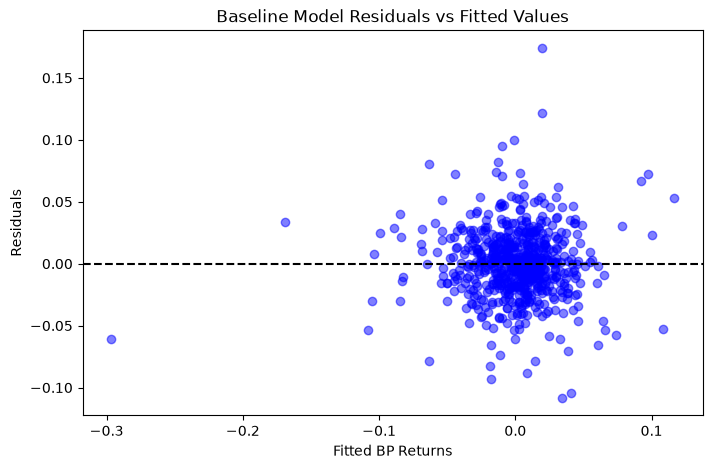

In [109]:
plt.figure(figsize=(8, 5))

plt.scatter(baseline_model.fittedvalues, baseline_model.resid, alpha=0.5, color="blue")

plt.axhline(y=0, color="black", linestyle="--", label="Zero Residual")

plt.xlabel("Fitted BP Returns")
plt.ylabel("Residuals")
plt.title("Baseline Model Residuals vs Fitted Values")
plt.show()

In [110]:
baseline_HAC = baseline_model.get_robustcov_results(cov_type='HAC', maxlags=4)

hac_results = pd.DataFrame({
    "Coefficient": baseline_HAC.params,
    "HAC Std_Error": baseline_HAC.bse,
    "HAC P_Value": baseline_HAC.pvalues,
}, index=baseline_model.params.index)

display(hac_results)

,Coefficient,HAC Std_Error,HAC P_Value
const,-0.000646,0.001063,5.440344e-01
Brent_Return,0.266812,0.037916,4.969565e-12
FTSE_Return,1.128291,0.089938,1.659048e-32
FX_Return,-0.199884,0.155411,1.988388e-01


In [111]:
asymmetric_hac = asymmetric_model.get_robustcov_results(cov_type='HAC', maxlags=4)

asymmetric_hac_results = pd.DataFrame({
    "Coefficient": asymmetric_hac.params,
    "HAC Std_Error": asymmetric_hac.bse,
    "HAC P_Value": asymmetric_hac.pvalues,
}, index=asymmetric_model.params.index) 

display(asymmetric_hac_results)

,Coefficient,HAC Std_Error,HAC P_Value
const,-0.001543,0.001552,3.207658e-01
Brent_Up,0.288781,0.068755,3.037497e-05
Brent_Down,0.244610,0.043753,3.323497e-08
FTSE_Return,1.137931,0.091757,7.201050e-32
FX_Return,-0.194130,0.158763,2.218588e-01


In [112]:
regime_interaction_hac = regime_interaction_model.get_robustcov_results(cov_type='HAC', maxlags=4)

regime_interaction_hac_results = pd.DataFrame({
    "Coefficient": regime_interaction_hac.params,
    "HAC Std_Error": regime_interaction_hac.bse,
    "HAC P_Value": regime_interaction_hac.pvalues,
}, index=regime_interaction_model.params.index)

display(regime_interaction_hac_results)

,Coefficient,HAC Std_Error,HAC P_Value
const,-0.002006,0.002071,3.330123e-01
Brent_Return,0.166871,0.045762,2.870812e-04
FTSE_Return,1.184357,0.094847,3.130966e-32
FX_Return,-0.155426,0.160552,3.333690e-01
Medium_Regime,0.000890,0.002637,7.358132e-01
High_Regime,0.003079,0.002631,2.422170e-01
Brent_x_Medium,0.181955,0.068363,7.968840e-03
Brent_x_High,0.188645,0.059327,1.544053e-03


The Breusch-Godfrey tests provide no evidence of residual autocorrelation at the 1-, 4-, 8- or 12-week lag lengths, with all p-values comfortably above 5%. The Breusch-Pagan test is borderline at the 5% level ($p = 0.050$), while the White test strongly rejects homoskedasticity ($p < 0.001$). This provides a clear reason to use HAC-robust standard errors for the main statistical inference.

Under four-lag HAC inference, the baseline Brent coefficient remains strongly significant at 0.267 ($p < 0.001$), as does the FTSE 100 coefficient at 1.128 ($p < 0.001$). In contrast, the GBP/USD coefficient is no longer statistically significant ($p = 0.199$). The evidence therefore supports Brent and broader equity-market exposure, but not a robust independent FX effect.

In the asymmetric specification, both the positive- and negative-Brent coefficients remain individually significant under HAC inference, at 0.289 and 0.245 respectively. However, the formal equality test remains insignificant ($p = 0.602$), so there is still no evidence that BP's sensitivity differs materially between upward and downward Brent moves.

The price-regime result is more robust. In the low-price reference regime, the Brent coefficient is 0.167. The medium- and high-price interaction terms are both positive and statistically significant, at 0.182 ($p = 0.008$) and 0.189 ($p = 0.002$) respectively. This implies Brent sensitivities of approximately 0.349 in the medium-price regime and 0.356 in the high-price regime.

The diagnostics therefore change one important conclusion from the conventional OLS results: the apparent GBP/USD effect is not robust. By contrast, the central Brent exposure and the stronger medium- and high-price regime sensitivities remain supported after correcting the inference for heteroskedasticity and possible short-run residual dependence.

### 8.1 HAC lag sensitivity

HAC inference is repeated using 1-, 4-, 8- and 12-week lag horizons to check whether the conclusions depend on the selected bandwidth.

In [113]:
# Test whether key inference conclusions are robust to alternative HAC lag lengths
hac_lag_results = []

for lag in [1, 4, 8, 12]:

    # Baseline model 
    baseline_hac_lag = baseline_model.get_robustcov_results(cov_type='HAC', maxlags=lag)
    baseline_pvalues = pd.Series(baseline_hac_lag.pvalues, index=baseline_model.params.index)
    baseline_bse = pd.Series(baseline_hac_lag.bse, index=baseline_model.params.index)   

    # Asymmetric model
    asymmetric_hac_lag = asymmetric_model.get_robustcov_results(cov_type='HAC', maxlags=lag)
    assymetric_test_lag = asymmetric_hac_lag.t_test("Brent_Up = Brent_Down")

    # Regime interaction model
    regime_interaction_hac_lag = regime_interaction_model.get_robustcov_results(cov_type='HAC', maxlags=lag)
    regime_joint_test_lag = regime_interaction_hac_lag.f_test("Brent_x_Medium = 0, Brent_x_High = 0")
    regime_interaction_pvalues = pd.Series(regime_interaction_hac_lag.pvalues, index=regime_interaction_model.params.index)

    hac_lag_results.append({
        "HAC Lag": lag,
        "Baseline Brent P-Value": baseline_pvalues["Brent_Return"],
        "Baseline_Brent SE": baseline_bse["Brent_Return"],
        "Asymmetric Brent P-Value": np.asarray(assymetric_test_lag.pvalue).item(),
        "Medium Interaction Brent P-Value": regime_interaction_pvalues["Brent_x_Medium"],
        "High Interaction Brent P-Value": regime_interaction_pvalues["Brent_x_High"],
        "Regime Interaction Joint P-Value": np.asarray(regime_joint_test_lag.pvalue).item()
    })

hac_lag_results_df = pd.DataFrame(hac_lag_results)
hac_lag_results_df = hac_lag_results_df.set_index("HAC Lag")
display(hac_lag_results_df)


,Baseline Brent P-Value,Baseline_Brent SE,Asymmetric Brent P-Value,Medium Interaction Brent P-Value,High Interaction Brent P-Value,Regime Interaction Joint P-Value
HAC Lag,,,,,,
1,1.128618e-12,0.036769,0.662027,0.011652,0.006277,0.012084
4,4.969565e-12,0.037916,0.608424,0.007969,0.001544,0.002740
8,2.883392e-10,0.041661,0.541765,0.007705,0.001077,0.001848
12,2.260697e-09,0.044009,0.514062,0.007331,0.000576,0.001001


Across HAC lag lengths of 1, 4, 8 and 12 weeks, the baseline Brent coefficient remains strongly significant, with p-values below $3\times10^{-9}$ in every specification. Its HAC standard error increases moderately from 0.0368 at one lag to 0.0440 at twelve lags, but this is not enough to alter the inference.

The asymmetry result is also stable: the p-value for the difference between upward and downward Brent sensitivity remains well above 5%, ranging from 0.662 to 0.514. There is therefore no evidence of directional asymmetry under any of the tested HAC lag choices.

In contrast, the price-regime effects remain consistently significant. The medium-regime interaction p-value ranges from 0.0117 to 0.0073, while the high-regime interaction ranges from 0.0063 to below 0.001. The joint test of the two regime interactions is significant at every lag length, with p-values between 0.0121 and 0.0010.

The main conclusions are therefore insensitive to the HAC lag specification: Brent exposure remains strongly supported, directional asymmetry remains unsupported, and the price-regime effect remains statistically robust.

## 9. Further conditional exposure tests

The price-regime result is the strongest conditional effect identified so far. Four additional specifications test whether BP's Brent sensitivity also changes during extreme oil moves, high-volatility periods, stressed equity markets or through a continuous nonlinear response.

From this point onward, new model development uses pre-2024 observations only so that 2024-2026 can be reserved for final holdout evaluation.

In [114]:
# Pre-2024 observations are used for model development, preserving 2024-2026 as the final holdout
development_data = weekly_data.loc[weekly_data.index < "2024-01-01"].copy()

### 9.1 Extreme Brent-move sensitivity

Extreme weeks are defined using the largest 20% of absolute Brent returns in the development sample. The interaction term tests whether BP's Brent sensitivity changes when oil prices move unusually sharply.

In [115]:
extreme_threshold = (development_data["Brent_Return"].abs().quantile(0.80))

development_data["Extreme_Brent"] = (development_data["Brent_Return"].abs() > extreme_threshold).astype(float)

development_data["Brent_x_Extreme"] = (development_data["Brent_Return"] * development_data["Extreme_Brent"])

print(f"Extreme-move threshold: {extreme_threshold:.2%}")

Extreme-move threshold: 6.18%


In [116]:
magnitude_features = [
    "Brent_Return", 
    "Extreme_Brent", 
    "Brent_x_Extreme", 
    "FTSE_Return", 
    "FX_Return"]

X_magnitude = sm.add_constant(development_data[magnitude_features])
y_magnitude = development_data["BP_Return"]

# HAC inference allows for heteroskedasticity and short-run residual dependence
magnitude_model = sm.OLS(y_magnitude, X_magnitude).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

magnitude_ci = magnitude_model.conf_int()

magnitude_results = pd.DataFrame({
    "Coefficient": magnitude_model.params,
    "HAC_Std_Error": magnitude_model.bse,
    "CI_Lower": magnitude_ci[0],
    "CI_Upper": magnitude_ci[1],
    "HAC_P_Value": magnitude_model.pvalues
})

display(magnitude_results)

ordinary_brent_beta = magnitude_model.params["Brent_Return"]

extreme_brent_beta = ordinary_brent_beta + magnitude_model.params["Brent_x_Extreme"]

print(f"Ordinary-move Brent beta: {ordinary_brent_beta:.3f}")
print(f"Extreme-move Brent beta: {extreme_brent_beta:.3f}")

,Coefficient,HAC_Std_Error,CI_Lower,CI_Upper,HAC_P_Value
const,-0.001448,0.001098,-0.003599,0.000703,1.871098e-01
Brent_Return,0.261150,0.043899,0.175109,0.347192,2.700414e-09
Extreme_Brent,0.004789,0.004479,-0.003989,0.013566,2.849719e-01
Brent_x_Extreme,-0.085809,0.062661,-0.208621,0.037004,1.708689e-01
FTSE_Return,1.267819,0.093734,1.084103,1.451534,1.103358e-41
FX_Return,-0.111943,0.165015,-0.435365,0.211480,4.975297e-01


Ordinary-move Brent beta: 0.261
Extreme-move Brent beta: 0.175


The estimated Brent beta is 0.261 during ordinary weeks and falls to approximately 0.175 during extreme-move weeks. The implied reduction in sensitivity is therefore about 0.086.

However, the Brent–extreme interaction is not statistically significant ($p = 0.171$), and its 95% confidence interval spans zero (-0.209 to 0.037). The extreme-move indicator itself is also insignificant ($p = 0.285$), providing no evidence of a separate return-level effect during these weeks.

The lower point estimate during extreme Brent moves is therefore economically noticeable but too imprecisely estimated to conclude that BP's commodity sensitivity systematically changes when oil prices move unusually sharply.

### 9.2 Volatility regime

A 13-week rolling standard deviation is used to represent the recent Brent volatility environment. The interaction term tests whether BP's Brent sensitivity differs between lower- and higher-volatility periods.

In [117]:
# A 13-week rolling standard deviation measures the recent Brent volatility environment
vol_data = weekly_data.copy()

vol_data["Brent_13W_Vol"] = (vol_data["Brent_Return"].rolling(window=13).std())

development_vol = vol_data.loc[vol_data.index < "2024-01-01"].dropna().copy()

vol_threshold = development_vol["Brent_13W_Vol"].median()

development_vol["High_Volatility"] = (development_vol["Brent_13W_Vol"] > vol_threshold).astype(float)

development_vol["Brent_x_HighVol"] = (development_vol["Brent_Return"] * development_vol["High_Volatility"])

print(f"Volatility threshold: {vol_threshold:.2%}")

Volatility threshold: 4.43%


In [118]:
vol_features = [
    "Brent_Return",
    "FTSE_Return",
    "FX_Return",
    "High_Volatility",
    "Brent_x_HighVol"
]

X_vol = sm.add_constant(development_vol[vol_features])
y_vol = development_vol["BP_Return"]

# Test whether Brent sensitivity changes between low- and high-volatility environments
vol_model = sm.OLS(y_vol, X_vol).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

vol_ci = vol_model.conf_int()

vol_results = pd.DataFrame({
    "Coefficient": vol_model.params,
    "HAC_Std_Error": vol_model.bse,
    "CI_Lower": vol_ci[0],
    "CI_Upper": vol_ci[1],
    "HAC_P_Value": vol_model.pvalues
})

display(vol_results)

low_vol_beta = vol_model.params["Brent_Return"]
high_vol_beta = low_vol_beta + vol_model.params["Brent_x_HighVol"]

print(f"Low-volatility Brent beta: {low_vol_beta:.3f}")
print(f"High-volatility Brent beta: {high_vol_beta:.3f}")

volatility_joint_test = vol_model.f_test("High_Volatility = 0, Brent_x_HighVol = 0")
print(volatility_joint_test)

,Coefficient,HAC_Std_Error,CI_Lower,CI_Upper,HAC_P_Value
const,-0.001540,0.001362,-0.004209,0.001129,2.580410e-01
Brent_Return,0.206960,0.053254,0.102584,0.311335,1.017842e-04
FTSE_Return,1.263018,0.091557,1.083569,1.442467,2.737854e-43
FX_Return,-0.114870,0.167856,-0.443861,0.214121,4.937620e-01
High_Volatility,0.002365,0.002432,-0.002401,0.007131,3.307469e-01
Brent_x_HighVol,-0.019772,0.062609,-0.142484,0.102940,7.521554e-01


Low-volatility Brent beta: 0.207
High-volatility Brent beta: 0.187
<F test: F=0.6700517067470425, p=0.5121382320729656, df_denom=503, df_num=2>


The estimated Brent beta is 0.207 in the low-volatility regime and 0.187 in the high-volatility regime, a difference of only 0.020.

The Brent–high-volatility interaction is not statistically significant ($p = 0.752$), and the high-volatility level effect is also insignificant ($p = 0.331$). The joint test of both volatility terms gives $p = 0.512$, so the model provides no evidence that either BP's average return level or its Brent sensitivity changes systematically between low- and high-volatility oil-market environments.

The volatility result is therefore much weaker than the price-regime result: recent Brent volatility does not appear to add a meaningful conditional exposure effect beyond the underlying Brent return itself.

### 9.3 Market stress

Market stress is defined using the weakest 20% of weekly FTSE 100 returns in the development sample. The model separates a general stress effect from a possible change in BP's Brent sensitivity during those weeks.

In [119]:
# Market stress is defined using the weakest 20% of weekly FTSE 100 returns
stress_data = development_data.copy()

stress_threshold = (stress_data["FTSE_Return"].quantile(0.20))

stress_data["Market_Stress"] = (stress_data["FTSE_Return"] <= stress_threshold).astype(float)

stress_data["Brent_x_Stress"] = (stress_data["Brent_Return"] * stress_data["Market_Stress"])

print(f"Market-stress threshold: {stress_threshold:.2%}")
print(f"Stress observations: {int(stress_data['Market_Stress'].sum())}")

Market-stress threshold: -1.46%
Stress observations: 105


In [120]:
stress_features = [
    "Brent_Return",
    "FTSE_Return",
    "FX_Return",
    "Market_Stress",
    "Brent_x_Stress"
]

X_stress = sm.add_constant(stress_data[stress_features])
y_stress = stress_data["BP_Return"]

# Test whether Brent sensitivity changes during stressed equity-market conditions
stress_model = sm.OLS(y_stress, X_stress).fit(cov_type="HAC",cov_kwds={"maxlags": 4})

stress_ci = stress_model.conf_int()

stress_results = pd.DataFrame({
    "Coefficient": stress_model.params,
    "HAC_Std_Error": stress_model.bse,
    "CI_Lower": stress_ci[0],
    "CI_Upper": stress_ci[1],
    "HAC_P_Value": stress_model.pvalues
})

display(stress_results)

normal_market_beta = stress_model.params["Brent_Return"]
stress_market_beta = normal_market_beta + stress_model.params["Brent_x_Stress"]

print(f"Normal-market Brent beta: {normal_market_beta:.3f}")
print(f"Stress-market Brent beta: {stress_market_beta:.3f}")

stress_joint_test = stress_model.f_test("Market_Stress = 0, Brent_x_Stress = 0")
print(stress_joint_test)

,Coefficient,HAC_Std_Error,CI_Lower,CI_Upper,HAC_P_Value
const,-0.003241,0.001387,-0.005960,-0.000522,1.947310e-02
Brent_Return,0.189517,0.042279,0.106652,0.272382,7.375924e-06
FTSE_Return,1.435536,0.115721,1.208727,1.662345,2.450634e-35
FX_Return,-0.090343,0.155935,-0.395970,0.215284,5.623426e-01
Market_Stress,0.014106,0.005196,0.003922,0.024291,6.633333e-03
Brent_x_Stress,-0.002087,0.066712,-0.132840,0.128666,9.750395e-01


Normal-market Brent beta: 0.190
Stress-market Brent beta: 0.187
<F test: F=4.4519529631348185, p=0.012107796926267008, df_denom=515, df_num=2>


The normal-market Brent beta is 0.190, while the stress-market beta is 0.187, so BP's estimated Brent sensitivity is effectively unchanged during stressed FTSE conditions. Consistent with this, the Brent–stress interaction is almost zero (-0.002) and statistically insignificant ($p = 0.975$).

The market-stress level effect is different. The stress indicator is positive and statistically significant at 0.014 ($p = 0.0066$), and the two stress terms are jointly significant ($F = 4.45$, $p = 0.012$).

This suggests that severe equity-market declines are associated with an additional shift in BP's return level after controlling for the continuous FTSE return, but not with a change in BP's Brent sensitivity.

The stress result is therefore different from the price-regime result: market stress affects the conditional level of BP returns, whereas the Brent price regime changes the slope of BP's exposure to oil-price movements.

### 9.4 Nonlinear Brent response

A squared Brent-return term is added to test whether the relationship changes smoothly with the magnitude of the oil-price move rather than through discrete regimes.

In [121]:
nonlinear_data = development_data.copy()

nonlinear_data["Brent_Return_Squared"] = (nonlinear_data["Brent_Return"] ** 2)

nonlinear_features = [
    "Brent_Return",
    "Brent_Return_Squared",
    "FTSE_Return",
    "FX_Return"
]

X_nonlinear = sm.add_constant(nonlinear_data[nonlinear_features])
y_nonlinear = nonlinear_data["BP_Return"]

# Test whether Brent exposure exhibits continuous nonlinear curvature
nonlinear_model = sm.OLS(y_nonlinear, X_nonlinear).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

nonlinear_ci = nonlinear_model.conf_int()

nonlinear_results = pd.DataFrame({
    "Coefficient": nonlinear_model.params,
    "HAC_Std_Error": nonlinear_model.bse,
    "CI_Lower": nonlinear_ci[0],
    "CI_Upper": nonlinear_ci[1],
    "HAC_P_Value": nonlinear_model.pvalues
})

display(nonlinear_results)

,Coefficient,HAC_Std_Error,CI_Lower,CI_Upper,HAC_P_Value
const,0.000398,0.001210,-0.001974,0.002770,7.422133e-01
Brent_Return,0.192156,0.036524,0.120570,0.263741,1.432007e-07
Brent_Return_Squared,-0.235141,0.174957,-0.578050,0.107768,1.789504e-01
FTSE_Return,1.226979,0.084588,1.061190,1.392768,1.119851e-47
FX_Return,-0.129658,0.163011,-0.449153,0.189837,4.263840e-01


The linear Brent coefficient remains positive and strongly significant at 0.192 ($p < 0.001$). The quadratic term is negative at -0.235, but is not statistically significant ($p = 0.179$), and its 95% confidence interval spans zero (-0.578 to 0.108).

This means there is no strong evidence that BP's Brent sensitivity changes smoothly as the size of the weekly Brent move increases. The data support a mainly linear relationship within this specification.

The result therefore contrasts with the earlier price-regime analysis: discrete changes in sensitivity across Brent price environments are supported, while a continuous quadratic form of nonlinearity is not.

## 10. Feature engineering and walk-forward model comparison

The statistically motivated specifications are now compared on their ability to generalise through time rather than on in-sample fit alone.

Additional lagged Brent returns, four-week Brent momentum, recent Brent volatility and BP's lagged return are included as broader challengers. These test whether delayed effects, recent oil-price trends, volatility or short-run persistence add useful information beyond contemporaneous Brent, FTSE and FX returns.

Models are compared using expanding-window walk-forward validation over 2019-2023. Each test year is predicted using only earlier observations, and any regime or stress thresholds are learned from the corresponding training sample only. The 2024-2026 period remains untouched for the final holdout.

In [122]:
# Additional features test whether recent market history improves the baseline exposure model
feature_data = weekly_data.copy()

feature_data["Brent_Lag1"] = (feature_data["Brent_Return"].shift(1))

feature_data["Brent_Lag4"] = (feature_data["Brent_Return"].shift(4))

feature_data["Brent_4W_Return"] = np.log(feature_data["Brent_USD"]/feature_data["Brent_USD"].shift(4))

feature_data["Brent_13W_Vol"] = feature_data["Brent_Return"].rolling(window=13).std()

feature_data["BP_Lag1"] = (feature_data["BP_Return"].shift(1))

feature_data = feature_data.dropna()

development_feature_data = feature_data.loc[feature_data.index < "2024-01-01"].copy()

In [123]:
def walk_forward_ols(data, features, start_test_year=2019):
    results = []

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year]
        test = data.loc[data.index.year == year]

        X_train = sm.add_constant(train[features], has_constant="add")
        X_test = sm.add_constant(test[features], has_constant="add")
        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()

        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
            "R-squared": r2_score(y_test, predictions)
        })

    return pd.DataFrame(results)


In [124]:
baseline_features = [
    "Brent_Return",
    "FTSE_Return",
    "FX_Return"
]

lagged_features = [
    "Brent_Return",
    "Brent_Lag1",
    "Brent_Lag4",
    "FTSE_Return",
    "FX_Return"
]

enhanced_features = [
    "Brent_Return",
    "Brent_Lag1",
    "Brent_Lag4",
    "Brent_4W_Return",
    "Brent_13W_Vol",
    "FTSE_Return",
    "FX_Return",
    "BP_Lag1"
]

wf_baseline = walk_forward_ols(development_feature_data, baseline_features)

wf_lagged = walk_forward_ols(development_feature_data, lagged_features)

wf_enhanced = walk_forward_ols(development_feature_data, enhanced_features)

In [125]:
def create_regime_features(data, low_threshold, high_threshold):
    features = data[["Brent_Return", "FTSE_Return", "FX_Return"]].copy()

    features["Medium_Regime"] = ((data["Brent_USD_Avg"] > low_threshold) &
        (data["Brent_USD_Avg"] <= high_threshold) ).astype(float)

    features["High_Regime"] = (data["Brent_USD_Avg"] > high_threshold).astype(float)

    features["Brent_x_Medium"] = (features["Brent_Return"] * features["Medium_Regime"])

    features["Brent_x_High"] = (features["Brent_Return"] * features["High_Regime"])

    return sm.add_constant(features, has_constant="add")

In [126]:
def walk_forward_regime_ols(data, start_test_year=2019):
    results = []

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year].copy()
        test = data.loc[data.index.year == year].copy()

        # Relearn Brent regime thresholds within each training window to prevent data leakage
        low_threshold = train["Brent_USD_Avg"].quantile(1/3)
        high_threshold = train["Brent_USD_Avg"].quantile(2/3)

        X_train = create_regime_features(
            train,
            low_threshold,
            high_threshold
        )

        X_test = create_regime_features(
            test,
            low_threshold,
            high_threshold
        )

        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()

        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
            "R-squared": r2_score(y_test, predictions)
        })

    return pd.DataFrame(results)

wf_regime = walk_forward_regime_ols(development_feature_data)

In [127]:
def walk_forward_magnitude_ols(data, start_test_year=2019):
    results = []

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year].copy()
        test = data.loc[data.index.year == year].copy()

        # Learn the extreme-move threshold from training data only
        threshold = (train["Brent_Return"].abs().quantile(0.80))

        for df in [train, test]:
            df["Extreme_Brent"] = (df["Brent_Return"].abs() > threshold).astype(float)
            df["Brent_x_Extreme"] = (df["Brent_Return"] * df["Extreme_Brent"])

        features = [
            "Brent_Return",
            "Extreme_Brent",
            "Brent_x_Extreme",
            "FTSE_Return",
            "FX_Return"
        ]

        X_train = sm.add_constant(train[features], has_constant="add")
        X_test = sm.add_constant( test[features], has_constant="add")

        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()

        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
            "R-squared": r2_score(y_test, predictions)
        })

    return pd.DataFrame(results)


wf_magnitude = walk_forward_magnitude_ols(development_feature_data)

In [128]:
def walk_forward_volatility_ols(data, start_test_year=2019):
    results = []

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year].copy()
        test = data.loc[data.index.year == year].copy()

        # Learn the high-volatility threshold from training data only
        vol_threshold = train["Brent_13W_Vol"].median()

        for df in [train, test]:
            df["High_Volatility"] = (df["Brent_13W_Vol"] > vol_threshold).astype(float)
            df["Brent_x_HighVol"] = (df["Brent_Return"] * df["High_Volatility"])

        features = [
            "Brent_Return",
            "FTSE_Return",
            "FX_Return",
            "High_Volatility",
            "Brent_x_HighVol"
        ]

        X_train = sm.add_constant(train[features], has_constant="add")
        X_test = sm.add_constant(test[features], has_constant="add")

        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()
        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
            "R-squared": r2_score(y_test, predictions)
        })

    return pd.DataFrame(results)


wf_volatility = walk_forward_volatility_ols(development_feature_data)

In [129]:
def walk_forward_stress_ols(data, start_test_year=2019):
    results = []

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year].copy()
        test = data.loc[data.index.year == year].copy()

        # Learn the market-stress threshold from training data only
        stress_threshold = (train["FTSE_Return"].quantile(0.20))

        for df in [train, test]:
            df["Market_Stress"] = (df["FTSE_Return"] <= stress_threshold).astype(float)
            df["Brent_x_Stress"] = (df["Brent_Return"] * df["Market_Stress"])

        features = [
            "Brent_Return",
            "FTSE_Return",
            "FX_Return",
            "Market_Stress",
            "Brent_x_Stress"
        ]

        X_train = sm.add_constant(train[features], has_constant="add")

        X_test = sm.add_constant(test[features], has_constant="add")

        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()

        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
            "R-squared": r2_score(y_test, predictions)
        })

    return pd.DataFrame(results)


wf_stress = walk_forward_stress_ols(development_feature_data)

In [130]:
def walk_forward_nonlinear_ols(data, start_test_year=2019):
    results = []

    data = data.copy()

    data["Brent_Return_Squared"] = (data["Brent_Return"] ** 2)

    features = [
        "Brent_Return",
        "Brent_Return_Squared",
        "FTSE_Return",
        "FX_Return"
    ]

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year].copy()
        test = data.loc[data.index.year == year].copy()

        X_train = sm.add_constant(train[features], has_constant="add")
        X_test = sm.add_constant( test[features], has_constant="add")

        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()
        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
            "R-squared": r2_score(y_test, predictions)
        })

    return pd.DataFrame(results)

wf_nonlinear = walk_forward_nonlinear_ols(development_feature_data)

In [131]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline OLS",
        "Lagged OLS",
        "Enhanced OLS",
        "Price-Regime OLS",
        "Extreme-Move OLS",
        "Volatility OLS",
        "Market-Stress OLS",
        "Quadratic OLS"
    ],

    "Mean MAE": [
        wf_baseline["MAE"].mean(),
        wf_lagged["MAE"].mean(),
        wf_enhanced["MAE"].mean(),
        wf_regime["MAE"].mean(),
        wf_magnitude["MAE"].mean(),
        wf_volatility["MAE"].mean(),
        wf_stress["MAE"].mean(),
        wf_nonlinear["MAE"].mean()
    ],

    "Mean RMSE": [
        wf_baseline["RMSE"].mean(),
        wf_lagged["RMSE"].mean(),
        wf_enhanced["RMSE"].mean(),
        wf_regime["RMSE"].mean(),
        wf_magnitude["RMSE"].mean(),
        wf_volatility["RMSE"].mean(),
        wf_stress["RMSE"].mean(),
        wf_nonlinear["RMSE"].mean()
    ],

    "Mean R-squared": [
        wf_baseline["R-squared"].mean(),
        wf_lagged["R-squared"].mean(),
        wf_enhanced["R-squared"].mean(),
        wf_regime["R-squared"].mean(),
        wf_magnitude["R-squared"].mean(),
        wf_volatility["R-squared"].mean(),
        wf_stress["R-squared"].mean(),
        wf_nonlinear["R-squared"].mean()
    ]
})

model_comparison = (
    model_comparison
    .sort_values("Mean R-squared", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison)

,Model,Mean MAE,Mean RMSE,Mean R-squared
0,Price-Regime OLS,0.024752,0.032714,0.484304
1,Market-Stress OLS,0.024482,0.032667,0.482476
2,Baseline OLS,0.024722,0.033003,0.473353
3,Extreme-Move OLS,0.024716,0.032892,0.473283
4,Enhanced OLS,0.024710,0.032977,0.472527
5,Volatility OLS,0.024798,0.033041,0.472435
6,Lagged OLS,0.024784,0.033008,0.471580
7,Quadratic OLS,0.024912,0.033367,0.467868


The price-regime and market-stress specifications are the strongest individual challengers in walk-forward validation.

The price-regime model achieves the highest mean out-of-sample $R^2$ at 0.484, compared with 0.473 for the baseline, while also reducing mean RMSE from 0.0330 to 0.0327. The market-stress model records the lowest mean MAE and RMSE at 0.0245 and 0.0327 respectively, with a mean $R^2$ of 0.482.

By contrast, the lagged, enhanced, extreme-move and volatility specifications provide only marginal changes relative to the baseline, while the quadratic model performs worse across all three metrics.

Because the price-regime and market-stress models provide the strongest individual out-of-sample performance, they are carried forward into one parsimonious combined challenger. The combined model retains the price-regime structure and the market-stress level effect, but excludes the unsupported Brent-stress interaction.

In [132]:
def create_combined_features(
    data,
    low_threshold,
    high_threshold,
    stress_threshold
    ):

    features = data[["Brent_Return", "FTSE_Return", "FX_Return"]].copy()

    features["Medium_Regime"] = ((data["Brent_USD_Avg"] > low_threshold) &
        (data["Brent_USD_Avg"] <= high_threshold)).astype(float)
    features["High_Regime"] = (data["Brent_USD_Avg"] > high_threshold).astype(float)

    features["Brent_x_Medium"] = (features["Brent_Return"] * features["Medium_Regime"])
    features["Brent_x_High"] = (features["Brent_Return"] * features["High_Regime"])

    features["Market_Stress"] = (data["FTSE_Return"] <= stress_threshold).astype(float)

    return sm.add_constant(features, has_constant="add")

In [133]:
def walk_forward_combined_ols(data, start_test_year=2019):
    results = []

    for year in range(start_test_year, 2024):
        train = data.loc[data.index.year < year].copy()
        test = data.loc[data.index.year == year].copy()

        # Relearn all regime thresholds within each training window
        low_threshold = (train["Brent_USD_Avg"].quantile(1/3))

        high_threshold = (train["Brent_USD_Avg"].quantile(2/3))

        stress_threshold = (train["FTSE_Return"].quantile(0.20))

        X_train = create_combined_features(
            train,
            low_threshold,
            high_threshold,
            stress_threshold
        )

        X_test = create_combined_features(
            test,
            low_threshold,
            high_threshold,
            stress_threshold
        )

        y_train = train["BP_Return"]
        y_test = test["BP_Return"]

        model = sm.OLS(y_train, X_train).fit()
        predictions = model.predict(X_test)

        results.append({
            "Year": year,
            "MAE": mean_absolute_error(
                y_test,
                predictions
            ),
            "RMSE": mean_squared_error(
                y_test,
                predictions
            ) ** 0.5,
            "R-squared": r2_score(
                y_test,
                predictions
            )
        })

    return pd.DataFrame(results)

wf_combined = walk_forward_combined_ols(development_feature_data)

display(wf_combined)

,Year,MAE,RMSE,R-squared
0,2019,0.014027,0.017678,0.528489
1,2020,0.037900,0.049601,0.636049
2,2021,0.026335,0.032835,0.441760
3,2022,0.023363,0.030886,0.488192
4,2023,0.020822,0.030239,0.392111


In [134]:
final_candidate_comparison = pd.DataFrame({
    "Model": [
        "Price-Regime OLS",
        "Market-Stress OLS",
        "Combined Regime + Stress OLS"
    ],

    "Mean MAE": [
        wf_regime["MAE"].mean(),
        wf_stress["MAE"].mean(),
        wf_combined["MAE"].mean()
    ],

    "Mean RMSE": [
        wf_regime["RMSE"].mean(),
        wf_stress["RMSE"].mean(),
        wf_combined["RMSE"].mean()
    ],

    "Mean R-squared": [
        wf_regime["R-squared"].mean(),
        wf_stress["R-squared"].mean(),
        wf_combined["R-squared"].mean()
    ]
})

display(final_candidate_comparison)

,Model,Mean MAE,Mean RMSE,Mean R-squared
0,Price-Regime OLS,0.024752,0.032714,0.484304
1,Market-Stress OLS,0.024482,0.032667,0.482476
2,Combined Regime + Stress OLS,0.024489,0.032248,0.497320


The combined regime-and-stress model provides the strongest overall development-stage performance. Its mean walk-forward $R^2$ rises to 0.497, compared with 0.484 for the price-regime model and 0.482 for the market-stress model. It also achieves the lowest mean RMSE at 0.03225, versus 0.03271 and 0.03267 respectively.

Mean MAE is effectively tied with the market-stress specification: 0.02449 for the combined model compared with 0.02448 for market stress. The difference is negligible, while the combined model performs better on both RMSE and $R^2$. This combined specification is therefore selected and carried into the final 2024–2026 holdout.

## 11. Final holdout validation

The final models are estimated using all pre-2024 observations and evaluated on the reserved 2024-2026 period. Brent-regime and market-stress thresholds are learned once from the training sample and then held fixed throughout the holdout.

In [ ]:
# Final holdout is separated only after model selection is complete
train_data = weekly_data.loc[weekly_data.index < "2024-01-01"].copy()
test_data = weekly_data.loc[weekly_data.index >= "2024-01-01"].copy()

print(f"Training observations: {len(train_data)}")
print(f"Holdout observations: {len(test_data)}")

Training observations: 521
Holdout observations: 138


In [ ]:
# Final regime and stress thresholds are learned from pre-2024 data only
final_low_threshold = (train_data["Brent_USD_Avg"].quantile(1/3))
final_high_threshold = (train_data["Brent_USD_Avg"].quantile(2/3))

final_stress_threshold = (train_data["FTSE_Return"].quantile(0.20))

print(f"Low/Medium Brent threshold: ${final_low_threshold:.2f}")
print(f"Medium/High Brent threshold: ${final_high_threshold:.2f}")
print(f"Market-stress threshold: {final_stress_threshold:.2%}")

Low/Medium Brent threshold: $55.61
Medium/High Brent threshold: $75.31
Market-stress threshold: -1.46%


In [137]:
# Baseline model
baseline_features = [
    "Brent_Return",
    "FTSE_Return",
    "FX_Return"
]

X_train_baseline = sm.add_constant(train_data[baseline_features], has_constant="add")
X_test_baseline = sm.add_constant(test_data[baseline_features], has_constant="add")

baseline_holdout_model = sm.OLS(train_data["BP_Return"], X_train_baseline).fit()

baseline_holdout_predictions = (baseline_holdout_model.predict(X_test_baseline))

# Price-regime model
X_train_regime = create_regime_features(
    train_data,
    final_low_threshold,
    final_high_threshold
)

X_test_regime = create_regime_features(
    test_data,
    final_low_threshold,
    final_high_threshold
)

regime_holdout_model = sm.OLS(train_data["BP_Return"], X_train_regime).fit()

regime_holdout_predictions = (regime_holdout_model.predict(X_test_regime))

# Combined price-regime + market-stress model
X_train_combined = create_combined_features(
    train_data,
    final_low_threshold,
    final_high_threshold,
    final_stress_threshold
)

X_test_combined = create_combined_features(
    test_data,
    final_low_threshold,
    final_high_threshold,
    final_stress_threshold
)

combined_holdout_model = sm.OLS(train_data["BP_Return"], X_train_combined).fit()

combined_holdout_predictions = (combined_holdout_model.predict(X_test_combined))

In [138]:
holdout_comparison = pd.DataFrame({
    "Model": [
        "Baseline OLS",
        "Price-Regime OLS",
        "Combined Regime + Stress OLS"
    ],

    "MAE": [
        mean_absolute_error(
            test_data["BP_Return"],
            baseline_holdout_predictions
        ),
        mean_absolute_error(
            test_data["BP_Return"],
            regime_holdout_predictions
        ),
        mean_absolute_error(
            test_data["BP_Return"],
            combined_holdout_predictions
        )
    ],

    "RMSE": [
        mean_squared_error(
            test_data["BP_Return"],
            baseline_holdout_predictions
        ) ** 0.5,
        mean_squared_error(
            test_data["BP_Return"],
            regime_holdout_predictions
        ) ** 0.5,
        mean_squared_error(
            test_data["BP_Return"],
            combined_holdout_predictions
        ) ** 0.5
    ],

    "R-squared": [
        r2_score(
            test_data["BP_Return"],
            baseline_holdout_predictions
        ),
        r2_score(
            test_data["BP_Return"],
            regime_holdout_predictions
        ),
        r2_score(
            test_data["BP_Return"],
            combined_holdout_predictions
        )
    ]
})

display(holdout_comparison)

,Model,MAE,RMSE,R-squared
0,Baseline OLS,0.026162,0.032522,0.321276
1,Price-Regime OLS,0.024964,0.031130,0.378130
2,Combined Regime + Stress OLS,0.025453,0.031528,0.362130


The price-regime model performs best across all three final holdout metrics. Relative to the baseline, MAE falls from 0.02616 to 0.02496 and RMSE from 0.03252 to 0.03113, while out-of-sample $R^2$ rises from 0.321 to 0.378.

The development-selected combined regime-and-stress model also improves on the baseline, achieving an $R^2$ of 0.362, but it underperforms the simpler price-regime specification on MAE, RMSE and $R^2$.

This is important because the combined model had performed best during pre-2024 walk-forward validation. Its weaker performance on the reserved 2024–2026 period shows that the additional market-stress term does not generalise strongly enough to justify the added complexity.

The final holdout therefore favours the more parsimonious price-regime model. Its improvement over the baseline indicates that allowing BP's Brent sensitivity to vary with the prevailing oil-price environment provides useful out-of-sample information, while further conditional complexity adds little.

The figure below compares realised BP returns with the price-regime and combined model predictions to show how closely each specification tracks week-to-week movements during the holdout period.

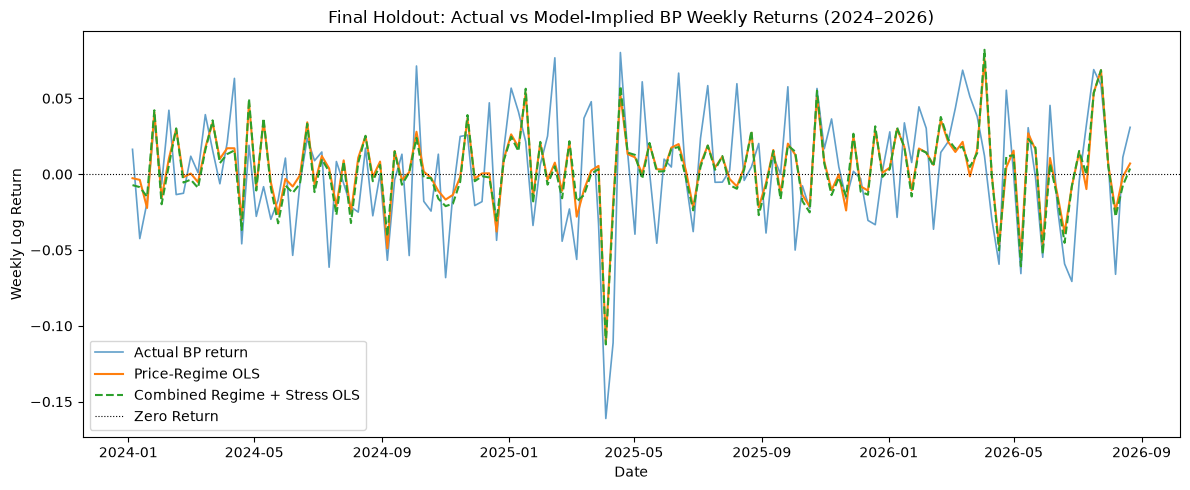

In [139]:
# Compare actual holdout returns with the two leading model specifications
plt.figure(figsize=(12, 5))

plt.plot(
    test_data.index,
    test_data["BP_Return"],
    label="Actual BP return",
    linewidth=1.2,
    alpha=0.7
)

plt.plot(
    test_data.index,
    regime_holdout_predictions,
    label="Price-Regime OLS",
    linewidth=1.5
)

plt.plot(
    test_data.index,
    combined_holdout_predictions,
    label="Combined Regime + Stress OLS",
    linewidth=1.5,
    linestyle="--"
)

plt.axhline(0, linewidth=0.8, linestyle=":", color="black", label="Zero Return")

plt.title("Final Holdout: Actual vs Model-Implied BP Weekly Returns (2024–2026)")
plt.xlabel("Date")
plt.ylabel("Weekly Log Return")
plt.legend()
plt.tight_layout()
plt.show()

The two conditional models track the broad direction of BP's weekly returns reasonably well, particularly during larger market moves, but they smooth over a substantial amount of the week-to-week variation in the realised series.

Both models capture several major positive and negative movements, including the sharp decline around April 2025, but neither reproduces the full magnitude of many of BP's return spikes. This is consistent with the holdout $R^2$ values: the models explain a meaningful share of BP's weekly return variation, but not all of it.

The price-regime and combined predictions are visually very similar across much of the holdout period. This reinforces the metric-based result that the additional market-stress component adds only limited incremental information beyond the simpler price-regime specification.

## 12. Valuation implications and conclusion

BP shows meaningful exposure to both oil prices and the broader equity market. In the baseline model, a 1% weekly Brent return is associated with approximately a 0.27% BP return after controlling for the FTSE 100 and GBP/USD. The FTSE coefficient is also large at 1.13, while the GBP/USD effect is not statistically significant under HAC inference.

BP's Brent sensitivity is not constant through time. The 52-week rolling beta averages 0.27 but ranges from approximately 0.02 to 0.61, showing substantial variation in the strength of BP's oil exposure across the sample.

The strongest explanation for this variation is the prevailing Brent price regime. In the pooled regime model, the estimated Brent beta is approximately 0.17 in the low-price regime, compared with 0.35 in both the medium- and high-price regimes. The medium- and high-price interaction effects remain significant under HAC inference, and the same pattern is retained under an alternative regime definition.

Other conditional effects are much weaker. There is no significant difference between BP's response to positive and negative Brent moves, while extreme Brent moves, recent Brent volatility and a quadratic Brent specification do not provide significant evidence of changing oil sensitivity. During stressed FTSE conditions, the Brent beta is also effectively unchanged at 0.19 in normal markets and 0.19 during stress; the significant stress effect operates through the return level rather than the Brent slope.

The out-of-sample results favour the same relatively simple interpretation. Although the combined regime-and-stress model achieved the strongest pre-2024 walk-forward performance with a mean R² of 0.497, the simpler price-regime model performed best on the reserved 2024–2026 holdout. Its holdout R² was 0.378, compared with 0.321 for the baseline and 0.362 for the combined model. It also reduced MAE from 0.0262 to 0.0250 and RMSE from 0.0325 to 0.0311 relative to the baseline.

### Valuation implications

The main valuation implication is that BP's exposure to Brent should not be represented by one fixed sensitivity across all oil-price environments. The historical evidence instead supports testing the DCF under distinct downside, base and upside Brent scenarios.

The historical regime thresholds are not forecasts of future Brent prices, and the regression coefficients are equity-return sensitivities rather than revenue or cash-flow elasticities. Forward-looking Brent assumptions must therefore be set separately, with each scenario translated through BP's operating assumptions and free cash flow.

### Conclusion

The analysis supports three main findings:

1. BP has significant historical exposure to Brent and to broader equity-market movements.
2. Brent sensitivity varies materially through time and is substantially stronger in medium- and high-price environments than in low-price environments.
3. Additional model complexity does not consistently improve out-of-sample performance, with the price-regime model producing the strongest final holdout results.

The central conclusion carried into the DCF is therefore that BP's commodity exposure is regime-dependent. The valuation should test how different forward-looking Brent environments affect BP's operating performance, cash generation and implied equity value rather than relying on a single oil-price assumption.